2021 populations: [12717.   18439.65 20983.05 11445.3 ]
2031 populations: [12580.90367155 18859.78615068 19691.44144343 14829.58303878]


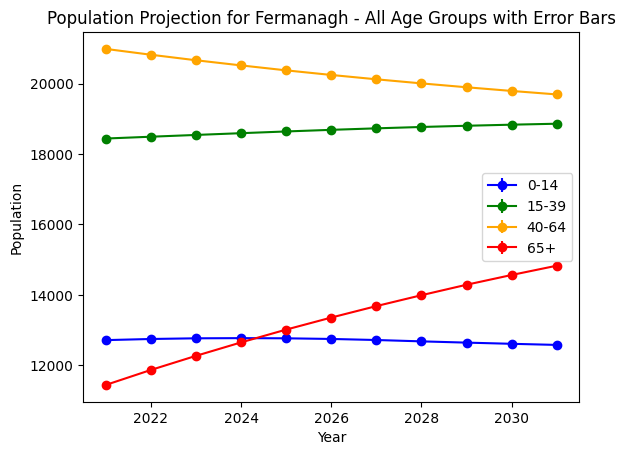

Errors: [[0.00000000e+00 7.19382702e-12 8.46332590e-12 1.69266518e-12]
 [2.99452156e+00 4.15047224e-01 1.07850405e+00 2.22765975e+00]
 [4.20745671e+00 6.04946620e-01 1.54462426e+00 3.28698110e+00]
 [4.83902854e+00 8.06562879e-01 1.78740303e+00 3.84823154e+00]
 [5.50315400e+00 1.05014862e+00 2.15028957e+00 3.94443262e+00]
 [5.76974304e+00 1.26553398e+00 2.33026670e+00 4.44217748e+00]
 [6.04142167e+00 1.54598269e+00 2.45158412e+00 4.84776193e+00]
 [6.44738060e+00 1.79814368e+00 2.49280648e+00 5.26827054e+00]
 [6.79945480e+00 2.02987973e+00 2.62109205e+00 5.69123301e+00]
 [6.98136475e+00 2.29295041e+00 2.72291538e+00 5.65990934e+00]
 [7.07382347e+00 2.56146578e+00 2.86205746e+00 6.25475717e+00]]
2031 errors for all age groups:
0-14: ± 7.073823469926222
15-39: ± 2.5614657828775496
40-64: ± 2.862057464307924
65+: ± 6.254757171759592


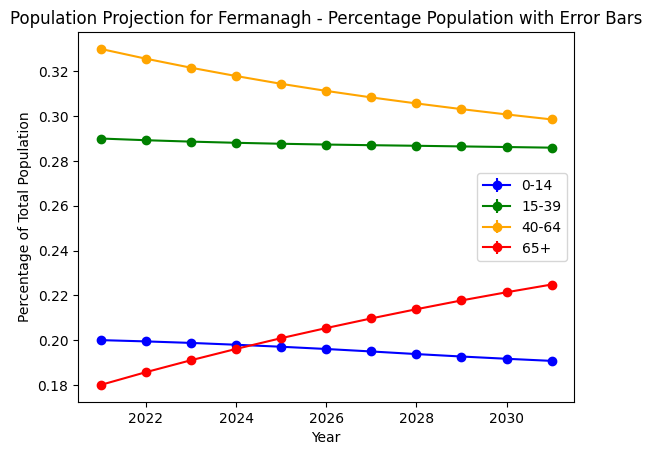

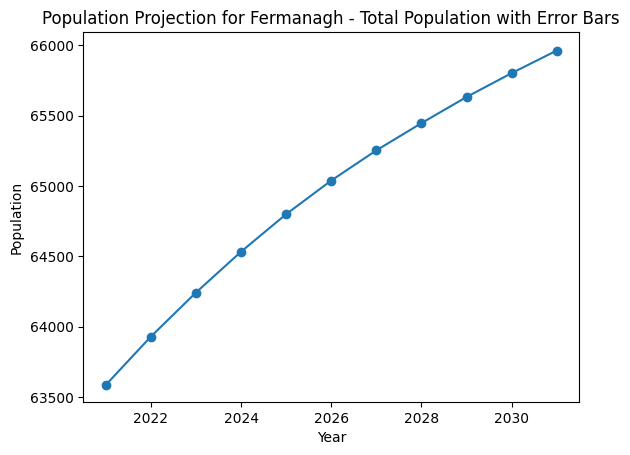

[0.2  0.29 0.33 0.18]
[0.19072974 0.28592052 0.29852887 0.22482087]


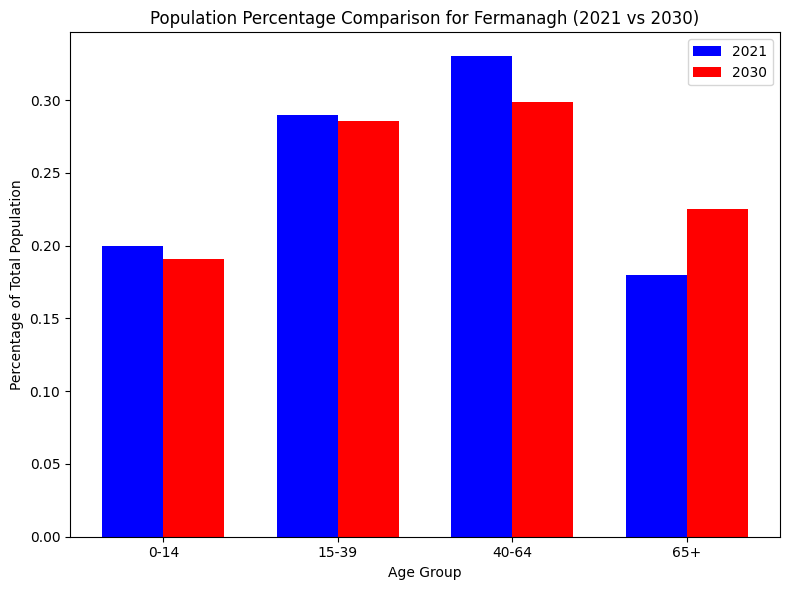

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats

def binomial(n,p):
    return np.sum(np.random.random(n) < p)

def xaxis(year):
    x = []
    for i in range(2021, year + 1):
        x.append(i)
    return x

baseYear = 2021
population = 63585
#63585 for Fermanagh and 116812 for Fermanagh and Omagh
populationsBA = population * np.array([0.2,0.29,0.33,0.18])
populationsFBA = populationsBA / 2
deathRates = np.array([0.00025, 0.00070, 0.00421, 0.03582])
migrationRates = np.array([0.0089, -0.0025, 0.0012, -0.0004])
numberOfYearsBA = np.array([15,25,25,10000])

#15-19, 20-24, 25-29, 30-34, 35-39, 40-44
fertileAgeDistribution = np.array([0.1635, 0.1475, 0.1609, 0.1743, 0.1796, 0.1743])
fertilityRates = np.array([0.0043, 0.0363, 0.0950, 0.1495, 0.0948, 0.0205])

def ageSimulationBA(simulatedYear, M):
    difference = simulatedYear + 1 - baseYear
    yearlyPopulation = np.zeros((M, difference, 4))
    yearly_pc_population = np.zeros((M, difference, 4))
    total_populations = np.zeros((M, difference))

    for m in range(M):
        currentPopulationsBA = populationsBA.copy()
        currentPopulationsFBA = populationsFBA.copy()
        current_fertility_rates = fertilityRates.copy()

        # RECORD YEAR 0 (2021) BEFORE ANY CHANGES
        yearlyPopulation[m, 0] = currentPopulationsBA
        total_population = np.sum(currentPopulationsBA)
        total_populations[m, 0] = total_population
        yearly_pc_population[m, 0] = currentPopulationsBA / total_population

        for i in range(1, difference):  # Start from 1, not 0
            fertilePopulation = currentPopulationsFBA[1] + (currentPopulationsFBA[2] * 0.20)
            fertileAgePopulation = fertileAgeDistribution * fertilePopulation

            births = 0
            for j in range(len(fertileAgePopulation)):
                births += binomial(int(fertileAgePopulation[j]), current_fertility_rates[j])

            agingOut = np.zeros(4)
            deaths = np.zeros(4)
            migrants = currentPopulationsBA * migrationRates

            for j in range(4):
                agingOut[j] = currentPopulationsBA[j] / numberOfYearsBA[j]
                deaths[j] = binomial(int(currentPopulationsBA[j]), deathRates[j])

            newPopulations = np.zeros(4)
            newPopulations[0] = currentPopulationsBA[0] + births - agingOut[0] - deaths[0] + migrants[0]
            newPopulations[1] = currentPopulationsBA[1] + agingOut[0] - agingOut[1] - deaths[1] + migrants[1]
            newPopulations[2] = currentPopulationsBA[2] + agingOut[1] - agingOut[2] - deaths[2] + migrants[2]
            newPopulations[3] = currentPopulationsBA[3] + agingOut[2] - deaths[3] + migrants[3]

            currentPopulationsBA = newPopulations
            total_population = np.sum(currentPopulationsBA)
            total_populations[m, i] = total_population
            cp_pc_BA = currentPopulationsBA / total_population
            currentPopulationsFBA = currentPopulationsBA / 2

            yearlyPopulation[m, i] = currentPopulationsBA
            yearly_pc_population[m, i] = cp_pc_BA
            currentYear = baseYear + i
            if 2021 < currentYear < 2028:
                current_fertility_rates = current_fertility_rates * 0.983425

    return yearlyPopulation, yearly_pc_population, total_populations

M = 200
years = xaxis(2031)
populationData = ageSimulationBA(2031, M)

age_group_labels = ['0-14', '15-39', '40-64', '65+']
colors = ['blue', 'green', 'orange', 'red']

means = np.mean(populationData[0], axis=0)
totalsmeans = np.mean(populationData[2], axis=0)
errors = 1.645*np.std(populationData[0], axis=0) / np.sqrt(M)
totalerrors = 1.645*np.std(populationData[2], axis=0) / np.sqrt(M)

print("2021 populations:", means[0])
print("2031 populations:", means[-1])

for i in range(4):
   plt.errorbar(years, means[:, i], yerr=errors[:, i], fmt='o-', color=colors[i], label=age_group_labels[i])

plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population Projection for Fermanagh - All Age Groups with Error Bars')
plt.legend()
plt.savefig('population_projection.png')
plt.show()

percentage_means = np.mean(populationData[1], axis=0)
percentage_errors = 1.645 * np.std(populationData[1], axis=0) / np.sqrt(M)

print("Errors:", errors)
print("2031 errors for all age groups:")
print("0-14: ±", errors[-1, 0])
print("15-39: ±", errors[-1, 1])
print("40-64: ±", errors[-1, 2])
print("65+: ±", errors[-1, 3])


for i in range(4):
    plt.errorbar(years, percentage_means[:, i], yerr=percentage_errors[:, i],
                 fmt='o-', color=colors[i], label=f'{age_group_labels[i]}')

plt.xlabel('Year')
plt.ylabel('Percentage of Total Population')
plt.title('Population Projection for Fermanagh - Percentage Population with Error Bars')
plt.legend()
plt.show()

plt.errorbar(years, totalsmeans, yerr=totalerrors, fmt='o-')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population Projection for Fermanagh - Total Population with Error Bars')
plt.show()

first_percentages = np.mean(populationData[1][:, 0], axis=0)
last_percentages = np.mean(populationData[1][:, -1], axis=0)


age_group_labels = ['0-14', '15-39', '40-64', '65+']
percentage_data = np.array([first_percentages, last_percentages])


fig, ax = plt.subplots(figsize=(8, 6))


bar_width = 0.35
index = np.arange(len(age_group_labels))

bar1 = ax.bar(index - bar_width / 2, percentage_data[0], bar_width, label='2021', color='blue')
bar2 = ax.bar(index + bar_width / 2, percentage_data[1], bar_width, label='2030', color='red')
print(percentage_data[0])
print(percentage_data[1])
ax.set_xlabel('Age Group')
ax.set_ylabel('Percentage of Total Population')
ax.set_title('Population Percentage Comparison for Fermanagh (2021 vs 2030)')
ax.set_xticks(index)
ax.set_xticklabels(age_group_labels)
ax.legend()

# Show the plot
plt.tight_layout()
plt.show()

